In [208]:
import numpy as np
import cv2
import math

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

from IPython.display import Image, display, HTML

In [211]:
coords_left = []

# Mouse callback for left image
def mouse_callback_left(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        if len(coords_left) < 32:
            coords_left.append([x,y,1])
            color = (255,255,255)
            cv2.circle(img_left, (x,y), 7, color, -1)
            cv2.imshow("LeftCameraScene", img_left)
        

img_left = cv2.imread("left-camera.jpeg")
cv2.imshow("LeftCameraScene", img_left)
cv2.setMouseCallback("LeftCameraScene", mouse_callback_left)

cv2.waitKey(0)
cv2.destroyAllWindows()
cv2.waitKey(1)


-1

In [212]:
coords_right = []

# Mouse callback for right image
def mouse_callback_right(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        if len(coords_right) < 32:
            coords_right.append([x,y,1])
            color = (255,255,255)
            cv2.circle(img_right, (x,y), 7, color, -1)
            cv2.imshow("RightCameraScene", img_right)

img_right = cv2.imread("right-camera.jpeg")
cv2.imshow("RightCameraScene", img_right)
cv2.setMouseCallback("RightCameraScene", mouse_callback_right)

cv2.waitKey(0)
cv2.destroyAllWindows()
cv2.waitKey(1)


-1

In [213]:
def afinize(vertex):
    vertex = vertex/vertex[2]
    return np.array([vertex[0], vertex[1]])

def homogeneous(vertex):
    vertex.append(1)

def eighth_vertex(vertices):
    x1 = np.cross(np.cross(vertices[1], vertices[4]), np.cross(vertices[2], vertices[5]))
    x2 = np.cross(np.cross(vertices[0], vertices[3]), np.cross(vertices[4], vertices[1]))
    x3 = np.cross(np.cross(vertices[0], vertices[3]), np.cross(vertices[2], vertices[5]))
    
    x1 = afinize(x1)
    x2 = afinize(x2)
    x3 = afinize(x3)
    x = list(1/3 * (x1 + x2 + x3))
    homogeneous(x)

    y1 = np.cross(np.cross(vertices[3], vertices[4]), np.cross(vertices[1], vertices[0]))
    y2 = np.cross(np.cross(vertices[3], vertices[4]), np.cross(vertices[5], vertices[6]))
    y3 = np.cross(np.cross(vertices[5], vertices[6]), np.cross(vertices[1], vertices[0]))

    y1 = afinize(y1)
    y2 = afinize(y2)
    y3 = afinize(y3)
    y = list(1/3 * (y1 + y2 + y3))
    homogeneous(y)

    missing = np.cross(np.cross(x, vertices[6]), np.cross(vertices[2], y))
    
    return list(np.round(missing/missing[2]))

In [214]:
B_l = np.array(coords_left[:7])
A_l = np.array(coords_left[7:14])
T_l = np.array(coords_left[14:18])
R_l = np.array(coords_left[18:25])
P_l = np.array(coords_left[25:32])


In [215]:
B_r = np.array(coords_right[:7])
A_r = np.array(coords_right[7:14])
T_r = np.array(coords_right[14:18])
R_r = np.array(coords_right[18:25])
P_r = np.array(coords_right[25:32])

In [216]:
b1_l,b2_l,b3_l,b4_l,b5_l,b6_l,b7_l = B_l
a1_l,a2_l,a3_l,a4_l,a5_l,a6_l,a7_l = A_l
t1_l, t2_l, t3_l, t4_l = T_l
r1_l,r2_l,r3_l,r4_l,r5_l,r6_l,r7_l = R_l
p1_l,p2_l,p3_l,p4_l,p5_l,p6_l,p7_l = P_l


In [217]:
b1_r,b2_r,b3_r,b4_r,b5_r,b6_r,b7_r = B_r
a1_r,a2_r,a3_r,a4_r,a5_r,a6_r,a7_r = A_r
t1_r, t2_r, t3_r, t4_r = T_r
r1_r,r2_r,r3_r,r4_r,r5_r,r6_r,r7_r = R_r
p1_r,p2_r,p3_r,p4_r,p5_r,p6_r,p7_r = P_r

In [218]:
# Calculate missing vertex
b8_l = np.array(list(map(int,eighth_vertex([b1_l,b2_l,b3_l,b4_l,b5_l,b6_l,b7_l]))))
b8_r = np.array(list(map(int,eighth_vertex([b1_r,b2_r,b3_r,b4_r,b5_r,b6_r,b7_r]))))

a8_l = np.array(list(map(int,eighth_vertex([a1_l,a2_l,a3_l,a4_l,a5_l,a6_l,a7_l]))))
a8_r = np.array(list(map(int,eighth_vertex([a1_r,a2_r,a3_r,a4_r,a5_r,a6_r,a7_r]))))

r8_l = np.array(list(map(int,eighth_vertex([r1_l,r2_l,r3_l,r4_l,r5_l,r6_l,r7_l]))))
r8_r = np.array(list(map(int,eighth_vertex([r1_r,r2_r,r3_r,r4_r,r5_r,r6_r,r7_r]))))

p8_l = np.array(list(map(int,eighth_vertex([p1_l,p2_l,p3_l,p4_l,p5_l,p6_l,p7_l]))))
p8_r = np.array(list(map(int,eighth_vertex([p1_r,p2_r,p3_r,p4_r,p5_r,p6_r,p7_r]))))

In [219]:
def draw_and_label_points(
    image, 
    points, 
    labels, 
    circle_color=(255,255,255),    
    text_color=(255,255,255),      
    radius=10, 
    thickness=4,
    font_scale=4
):
    for (pt, lbl) in zip(points, labels):
        x, y, _ = pt  # each point is [x, y, 1]
        x, y = int(x), int(y)

        # Draw the circle
        cv2.circle(image, (x, y), radius, circle_color, -1)

        # Put the text slightly above and to the right
        cv2.putText(
            image, lbl, (x + 7, y - 7), 
            cv2.FONT_HERSHEY_PLAIN, 
            font_scale, 
            text_color, 
            thickness
        )

In [220]:

labels_B_l = [f"b{i+1}_l" for i in range(len(B_l))]
labels_A_l = [f"a{i+1}_l" for i in range(len(A_l))]
labels_T_l = [f"t{i+1}_l" for i in range(len(T_l))]
labels_R_l = [f"r{i+1}_l" for i in range(len(R_l))]
labels_P_l = [f"p{i+1}_l" for i in range(len(P_l))]

image_left = cv2.imread("left-camera.jpeg")

left_points_red = [b8_l, a8_l, r8_l, p8_l] 
left_labels_red = ["b8_l", "a8_l", "r8_l", "p8_l"]

draw_and_label_points(
    image_left, 
    left_points_red, 
    left_labels_red, 
    circle_color=(0,0,255),    # Red circles
    text_color=(0,0,255)       
)

draw_and_label_points(image_left, B_l, labels_B_l)
draw_and_label_points(image_left, A_l, labels_A_l)
draw_and_label_points(image_left, T_l, labels_T_l)
draw_and_label_points(image_left, R_l, labels_R_l)
draw_and_label_points(image_left, P_l, labels_P_l)

cv2.imwrite("left-points.png", image_left)



True

In [221]:
labels_B_r = [f"b{i+1}_r" for i in range(len(B_r))]
labels_A_r = [f"a{i+1}_r" for i in range(len(A_r))]
labels_T_r = [f"t{i+1}_r" for i in range(len(T_r))]
labels_R_r = [f"r{i+1}_r" for i in range(len(R_r))]
labels_P_r = [f"p{i+1}_r" for i in range(len(P_r))]

image_right = cv2.imread("right-camera.jpeg")

right_points_red = [b8_r, a8_r, r8_r, p8_r] 
right_labels_red = ["b8_r", "a8_r", "r8_r", "p8_r"]

draw_and_label_points(
    image_right,
    right_points_red,
    right_labels_red,
    circle_color=(0,0,255),
    text_color=(0,0,255)
)

draw_and_label_points(image_right, B_r, labels_B_r)
draw_and_label_points(image_right, A_r, labels_A_r)
draw_and_label_points(image_right, T_r, labels_T_r)
draw_and_label_points(image_right, R_r, labels_R_r)
draw_and_label_points(image_right, P_r, labels_P_r)

cv2.imwrite("right-points.png", image_right)

True

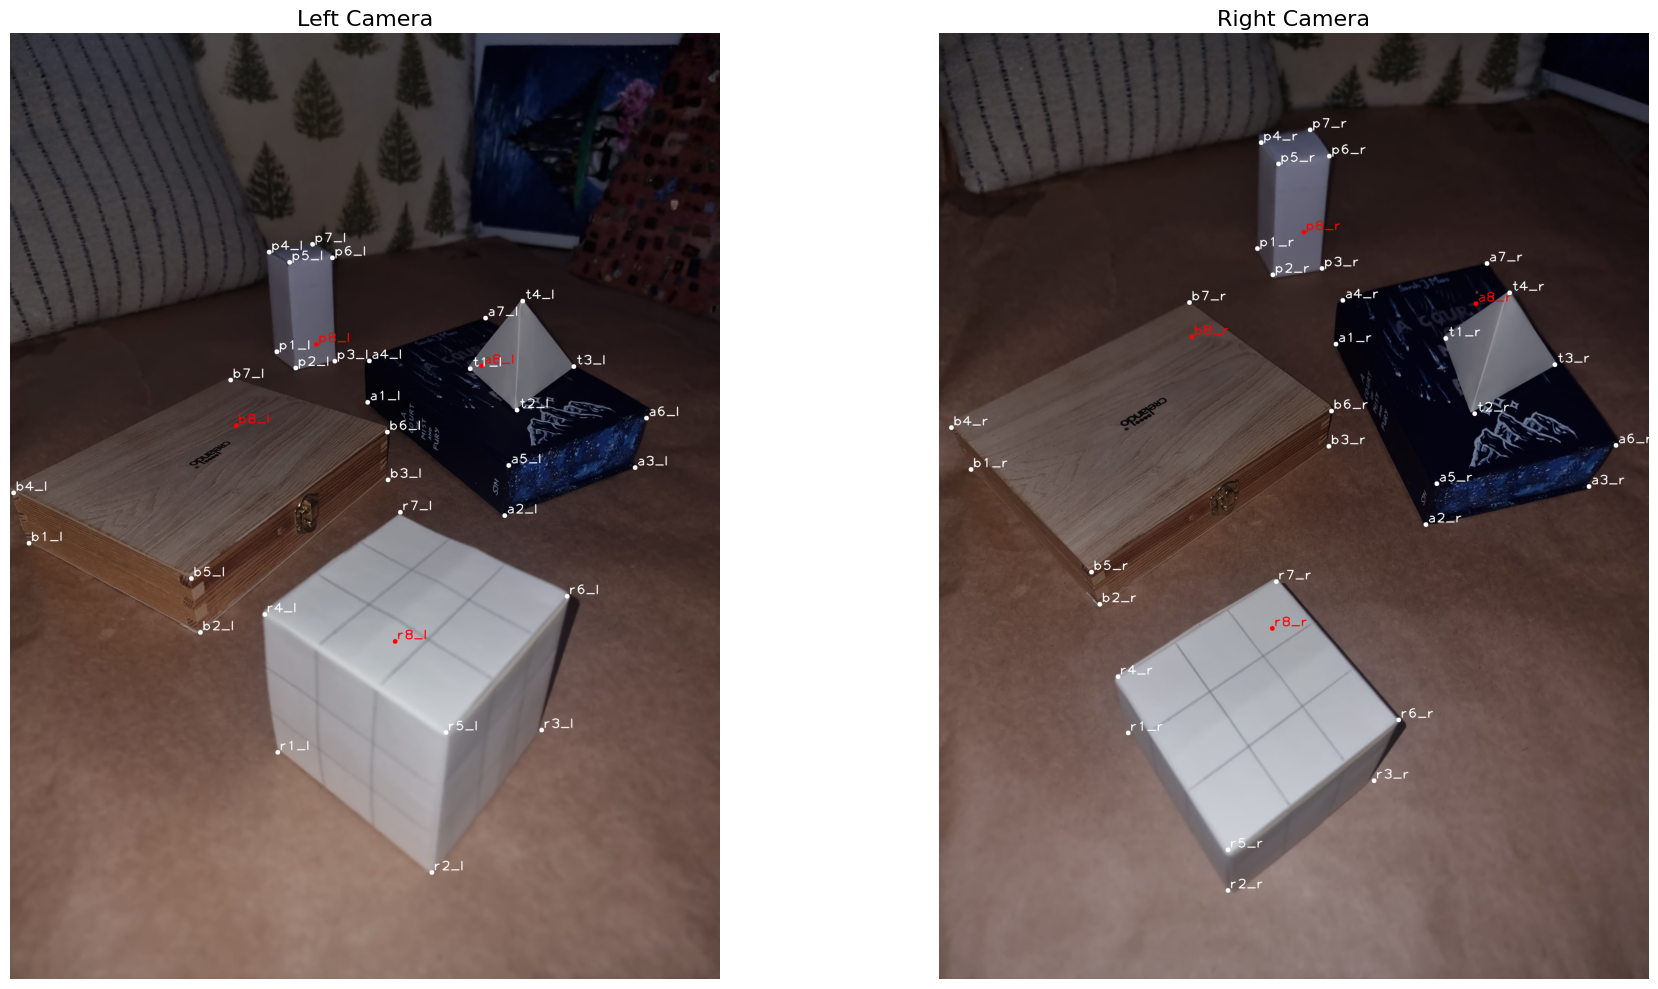

In [223]:
# Load the images
left_image = cv2.imread("left-points.png")
right_image = cv2.imread("right-points.png")

# Convert BGR (OpenCV default) to RGB (matplotlib format)
left_image_rgb = cv2.cvtColor(left_image, cv2.COLOR_BGR2RGB)
right_image_rgb = cv2.cvtColor(right_image, cv2.COLOR_BGR2RGB)

# Create a figure to display the images side by side
fig, axs = plt.subplots(1, 2, figsize=(20, 10))

# Display the left camera image
axs[0].imshow(left_image_rgb)
axs[0].axis('off')  # Turn off axes
axs[0].set_title("Left Camera", fontsize=16)

# Display the right camera image
axs[1].imshow(right_image_rgb)
axs[1].axis('off')  # Turn off axes
axs[1].set_title("Right Camera", fontsize=16)

# Show the plot
plt.tight_layout()
plt.show()

In [224]:
B_l = np.vstack([B_l, b8_l])
B_r = np.vstack([B_r, b8_r])

A_l = np.vstack([A_l, a8_l])
A_r = np.vstack([A_r, a8_r])

R_l = np.vstack([R_l, r8_l])
R_r = np.vstack([R_r, r8_r])

P_l = np.vstack([P_l, p8_l])
P_r = np.vstack([P_r, p8_r])


## Fundamental Matrix

In [225]:
def fundamental_matrix(left, right):
    n_9 = []
    for l , r in zip(left,right):
        a1, a2, a3 = l
        b1, b2, b3 = r
        n_9.append([a1*b1, a2*b1, a3*b1, a1*b2, a2*b2, a3*b2, a1*b3, a2*b3, a3*b3])
    
    n_9 = np.array(n_9)
    U, S, Vh = np.linalg.svd(n_9)
    F_vector = Vh[-1, :]/Vh[-1,-1]
    F = F_vector.reshape((3,3))
    
    return F
        

In [226]:
left = np.array([b1_l, b2_l, b4_l, b5_l, b6_l, b7_l, b8_l, a1_l, a2_l, a3_l, a4_l, a5_l, a6_l, a7_l, a8_l, t1_l, t2_l, t3_l, t4_l, r1_l, r2_l, r3_l, r4_l, r5_l, r6_l, r7_l, r8_l, p1_l, p2_l, p4_l, p5_l, p6_l, p7_l])
right = np.array([b1_r, b2_r, b4_r, b5_r, b6_r, b7_r, b8_r, a1_r, a2_r, a3_r, a4_r, a5_r, a6_r, a7_r, a8_r, t1_r, t2_r, t3_r, t4_r, r1_r, r2_r, r3_r, r4_r, r5_r, r6_r, r7_r, r8_r, p1_r, p2_r, p4_r, p5_r, p6_r, p7_r])

#transform
left[:, 0] = 4000 - left[:, 0]
right[:, 0] = 4000 - right[:, 0]

In [227]:
F= fundamental_matrix(left, right)
print(f"Fundamental matrix:\n {F}")
print()

# Check is det of F close to 0
print(f"det(F) = {np.linalg.det(F)}")

Fundamental matrix:
 [[ 5.61836021e-08 -3.50532834e-08  6.99384859e-04]
 [ 8.93775385e-08 -1.78715859e-08 -5.73589609e-04]
 [-1.15236470e-03  3.35394191e-04  1.00000000e+00]]

det(F) = -3.670549526916713e-15


## Essential Matrix

In [228]:
# Calibration matrix K1 = K2 = K
K = np.array([[2800, 0, 2000],
            [0, 2800, 1500],
            [0, 0, 1]])

In [229]:
E = np.matmul(np.matmul(K.T, F), K)
print(f"Essential matrix:\n {E}")

Essential matrix:
 [[ 0.44047944 -0.27481774  2.12568199]
 [ 0.7007199  -0.14011323 -1.18059735]
 [-2.53660732  0.66774469  0.0842433 ]]


## Decomposition of Essential Matrix

In [230]:
Q0 = np.array([[0, -1, 0],
            [1, 0, 0],
            [0, 0, 1]])
E0 =  np.array([[0, -1, 0],
            [1, 0, 0],
            [0, 0, 0]])

In [231]:
U, S, Vh = np.linalg.svd(-E)
# Check sign for det(U) and det(Vh)
print(f"det(U) = {np.linalg.det(U)}, det(Vh) = {np.linalg.det(Vh)}")

det(U) = 0.9999999999999998, det(Vh) = 1.0000000000000007


In [232]:
Ec = np.matmul(np.matmul(U, E0), U.T)
Aa = np.matmul(np.matmul(U,Q0.T),Vh)

print(f"Ec: \n{Ec}")
print(f"Aa: \n{Aa}")

#check det(A) = 1
print(f"\ndet(A) = {np.linalg.det(Aa)}")

Ec: 
[[ 1.32535090e-17  3.12673962e-01 -8.36005511e-01]
 [-3.12673962e-01  7.35808857e-18  4.50921033e-01]
 [ 8.36005511e-01 -4.50921033e-01 -2.50639099e-19]]
Aa: 
[[ 0.9641935   0.21790027 -0.15116336]
 [-0.2461287   0.94750014 -0.20411799]
 [ 0.09874994  0.23401489  0.96720498]]

det(A) = 1.0000000000000004


In [233]:
C = [Ec[2,1], Ec[0,2], Ec[1,0]]
print(f"Centar of left camera in coordinate system of right camera (WCS): \n {C}")

Centar of left camera in coordinate system of right camera (WCS): 
 [-0.45092103306463815, -0.8360055114220357, -0.31267396247833035]


## Camera Matrix

In [234]:
T2 = np.hstack((K, np.array([0, 0, 0]).reshape(-1,1)))
print(f"Camera matrix for right camera in coordinate system of right camera (WSC):")
print(np.array2string(T2, formatter={'all': lambda x: f"{x:6}"}))

Camera matrix for right camera in coordinate system of right camera (WSC):
[[  2800      0   2000      0]
 [     0   2800   1500      0]
 [     0      0      1      0]]


In [235]:
T1 = np.hstack((np.matmul(K, Aa.T), np.matmul(K,np.matmul(-Aa.T,C)).reshape(-1,1)))
print(f"Camera matrix for left camera in coordinate system of right camera (WSC):")
print(np.array2string(T1, formatter={'all': lambda x: f"{x:10.6f}"}))

Camera matrix for left camera in coordinate system of right camera (WSC):
[[2397.415081 -1097.396352 2210.909807 854.909417]
 [383.375703 2346.823389 2106.049157 2793.336191]
 [ -0.151163  -0.204118   0.967205   0.063613]]


## Triangulation

In [236]:
def triangulation(T1, T2, M1, M2):
    x1, y1, _ = M1
    x2, y2, _ = M2
    m = np.array([
        T1[2,:]*y1 - T1[1,:],
        -T1[2,:]*x1 + T1[0,:],
        T2[2,:]*y2 - T2[1,:],
        -T2[2,:]*x2 + T2[0,:]
    ])
    U, S, Vh = np.linalg.svd(m)
    M = Vh[-1,:]/Vh[-1,-1]
    return M
    

In [237]:
B_l[:, 0] = 4000 - B_l[:, 0]
B_r[:, 0] = 4000 - B_r[:, 0]
box_points = np.array(list(map(lambda pair: triangulation(T1, T2, pair[0], pair[1]),
                     zip(B_l, B_r))))

A_l[:, 0] = 4000 - A_l[:, 0]
A_r[:, 0] = 4000 - A_r[:, 0]
acotar_points = np.array(list(map(lambda pair: triangulation(T1, T2, pair[0], pair[1]),
                     zip(A_l, A_r))))

T_l[:, 0] = 4000 - T_l[:, 0]
T_r[:, 0] = 4000 - T_r[:, 0]
tetraeder_points = np.array(list(map(lambda pair: triangulation(T1, T2, pair[0], pair[1]),
                     zip(T_l, T_r))))

R_l[:, 0] = 4000 - R_l[:, 0]
R_r[:, 0] = 4000 - R_r[:, 0]
rubic_points = np.array(list(map(lambda pair: triangulation(T1, T2, pair[0], pair[1]),
                     zip(R_l, R_r))))

P_l[:, 0] = 4000 - P_l[:, 0]
P_r[:, 0] = 4000 - P_r[:, 0]
paralelepiped_points = np.array(list(map(lambda pair: triangulation(T1, T2, pair[0], pair[1]),
                     zip(P_l, P_r))))


In [238]:
print("Box points:")
for i, point in enumerate(box_points):
    print(f"Point {i}: {np.round(point, 4)}")
print("\nTetraeder points:")
for i, point in enumerate(tetraeder_points):
    print(f"Point {i}: {np.round(point, 4)}")

Box points:
Point 0: [-1.9536 -0.4112 -3.0701  1.    ]
Point 1: [-1.2355 -0.9033 -2.7066  1.    ]
Point 2: [-0.5376 -0.3946 -4.3844  1.    ]
Point 3: [-1.9551 -0.2176 -2.9706  1.    ]
Point 4: [-1.1925 -0.7303 -2.5542  1.    ]
Point 5: [-0.4822 -0.1537 -4.1082  1.    ]
Point 6: [-1.4785  0.5627 -4.6877  1.    ]
Point 7: [-1.5798  0.3454 -5.0571  1.    ]

Tetraeder points:
Point 0: [ 0.2692  0.3977 -5.3327  1.    ]
Point 1: [ 0.3989 -0.1618 -4.4779  1.    ]
Point 2: [ 1.1068  0.2043 -5.2938  1.    ]
Point 3: [ 0.7137  0.7018 -4.8786  1.    ]


In [245]:
def plot_shape_with_edges(points_3d, edges_3d, color='blue', fig=None, show=True):
    
    # If no figure provided, create a new one
    if fig is None:
        fig = go.Figure()

    # Plot each edge as a separate Scatter3d trace
    for (start_idx, end_idx) in edges_3d:
        x_vals = [points_3d[start_idx, 0], points_3d[end_idx, 0]]
        y_vals = [points_3d[start_idx, 1], points_3d[end_idx, 1]]
        z_vals = [points_3d[start_idx, 2], points_3d[end_idx, 2]]
        
        fig.add_trace(
            go.Scatter3d(
                x=x_vals,
                y=y_vals,
                z=z_vals,
                mode='lines+markers',  # Draw line + vertices
                line=dict(color=color, width=3),
                marker=dict(size=5, color=color),
                showlegend=False
            )
        )

    # Make the aspect ratio more "cube-like"
    fig.update_layout(
        scene=dict(aspectmode='cube'),
        title="3D Scene Reconstructon"
    )

    # Show (only if requested)
    if show:
        fig.show()
    
    return fig


def plot_camera_axes(camera_axes, camera_center, scale=0.5, fig=None):
    
    
    if fig is None:
        fig = go.Figure()
    
    # Define colors for each axis
    axis_colors = {'X': 'crimson', 'Y': 'seagreen', 'Z': 'steelblue'}
    axis_labels = {'X': 'Right', 'Y': 'Up', 'Z': 'Forward'}
    
    # Plot each axis
    for i, axis in enumerate(['X', 'Y', 'Z']):
        # Starting point is the camera center
        start = camera_center
        # Ending point is the camera center plus the axis vector scaled
        end = camera_center + camera_axes[:, i] * scale
        
        fig.add_trace(
            go.Scatter3d(
                x=[start[0], end[0]],
                y=[start[1], end[1]],
                z=[start[2], end[2]],
                mode='lines+markers',
                line=dict(color=axis_colors[axis], width=5),
                marker=dict(size=5, color=axis_colors[axis]),
                name=f'Camera {axis} Axis',
                showlegend=True
            )
        )
    
    # Plot the camera center
    fig.add_trace(
        go.Scatter3d(
            x=[camera_center[0]],
            y=[camera_center[1]],
            z=[camera_center[2]],
            mode='markers',
            marker=dict(color='black', size=8),
            name='Camera Center',
            showlegend=True
        )
    )
    
    return fig


In [246]:
edges = np.array([
    (0, 1), (1, 2), (2, 7), (7, 0),
    (0, 3), (3, 4), (4, 5),
    (5, 6), (6, 3), (1, 4),
    (2, 5),(7, 6)
])

# Define edges for the Tetrahedron
edges_tetra = np.array([
    [0, 1], 
    [1, 2],  
    [2, 3],
    [3, 0],
    [3, 1],
    [0, 2] 
])

fig = go.Figure()

# Plot Box
fig = plot_shape_with_edges(
    points_3d=np.stack(box_points)[:, :3], 
    edges_3d=edges, 
    color='darkred', 
    fig=fig, 
    show=False,
)

# Plot Book
fig = plot_shape_with_edges(
    points_3d=np.stack(acotar_points)[:, :3], 
    edges_3d=edges, 
    color='darkblue', 
    fig=fig, 
    show=False,
)

# Plot Tetrahedron
fig = plot_shape_with_edges(
    points_3d=np.stack(tetraeder_points)[:, :3], 
    edges_3d=edges_tetra, 
    color='darkorchid', 
    fig=fig, 
    show=False,
)

# Plot Cube
fig = plot_shape_with_edges(
    points_3d=np.stack(rubic_points)[:, :3], 
    edges_3d=edges, 
    color='darkgreen', 
    fig=fig, 
    show=False,
)

# Plot Paralelepiped
fig = plot_shape_with_edges(
    points_3d=np.stack(paralelepiped_points)[:, :3], 
    edges_3d=edges, 
    color='coral', 
    fig=fig, 
    show=False,
)

# Plot Camera Axes and Center
fig = plot_camera_axes(
    camera_axes=Aa, 
    camera_center=C, 
    scale=0.5,  # Adjust the scale as needed
    fig=fig
)

fig.show()






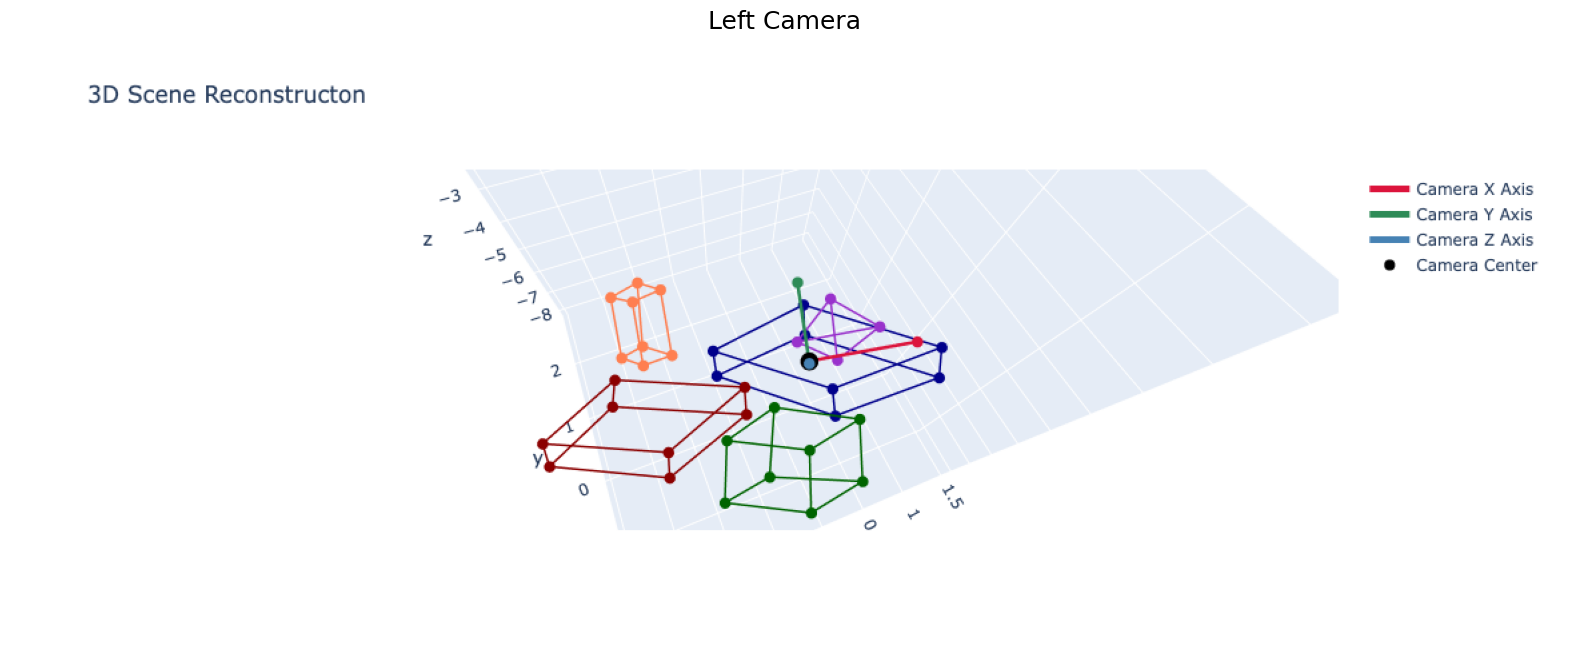

In [248]:
import cv2
import matplotlib.pyplot as plt

# Load the image
left_image = cv2.imread("3d-reconstructed.png")

# Convert BGR (OpenCV default) to RGB (matplotlib format)
left_image_rgb = cv2.cvtColor(left_image, cv2.COLOR_BGR2RGB)

# Display the image
plt.figure(figsize=(20, 20))  # Set the figure size
plt.imshow(left_image_rgb)
plt.axis('off')  # Turn off axes
plt.title("Left Camera", fontsize=18)  # Add a title with larger font size
plt.show()
